In [56]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT
from python_files import ETLM_code as ETLMC
from python_files import LETLM_code as LETLMC


torch.set_default_dtype(torch.float64)







The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
# We will now define a function that selects the 9 members of each row 
def member_past_selector(grid_index,X,N,ensemble_size):
    subset = torch.zeros(13,ensemble_size)
    for i in range(11):
        j = (grid_index +i - 8)%N
        # print(grid_index, j)
        subset[i,:] = X[j,:]
    return subset

def member_current_selector(grid_index,Xi,N,ensemble_size):
    subset = torch.zeros(1,ensemble_size)
    j = grid_index
    subset[0,:] = Xi[j,:]
    # print(subset.shape)
    return subset



def little_LETLM(current_subset, past_subset):
    etlm = current_subset @ past_subset.T@(torch.pinverse(past_subset@ past_subset.T))
    return etlm

def put_in_place(M_i, N, M, i):
    # M_i shape is (1, 9)
    M_i = M_i.squeeze() 
    # We are calculating the dependencies for output i
    # So we fill ROW i, across the 9 columns that contributed to it
    for k in range(11):
        input_idx = (i + k - 8) % N
        M[i, input_idx] = M_i[k] # Note: row i, column input_idx
    return M

In [58]:
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_96 = 8 # The Lorenz 96 forcing ter
dt = 0.1 # This gives a time step of six hours
timesteps =  30   #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_96)


100%|██████████| 90/90 [00:00<00:00, 10855.45it/s]

torch.Size([40])


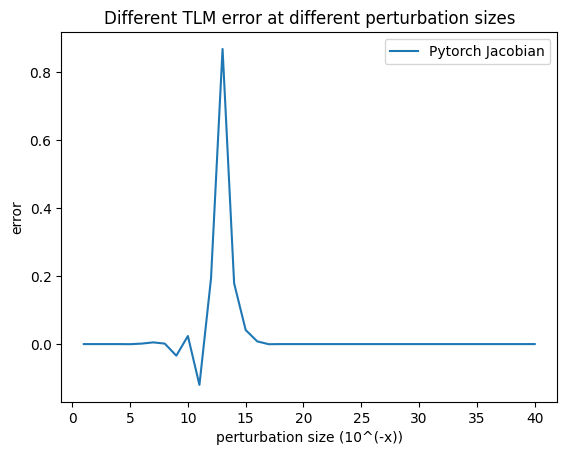

In [59]:
# I will now attempt to recreate a single line of the ETLM using the LETLM 
# We will use a perturbation size of 10**(-7) 
sd = 10**(-7)
x_values = np.arange(1, N+1)  
grid_index = 12


#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  30   #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_96)
model = bf.rk4_L96

# We now need to spin up the model 

spin_up_time = 1000
x_0 = torch.randn(N,1)
x = LETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x.clone()

# We will now generate the ETLM
ensemble_size = 90
ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)
# we will now grab out the 21st row and try to recreate it using the LETLM 

goal = ETLM[grid_index,:]
print(goal.shape)

plt.plot(x_values, goal,label = 'Pytorch Jacobian' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()


  0%|          | 0/16 [00:00<?, ?it/s]/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_50565/3006572819.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
100%|██████████| 16/16 [00:00<00:00, 1774.99it/s]


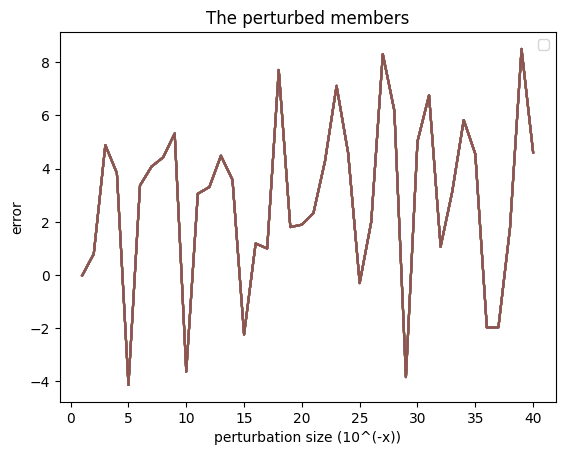

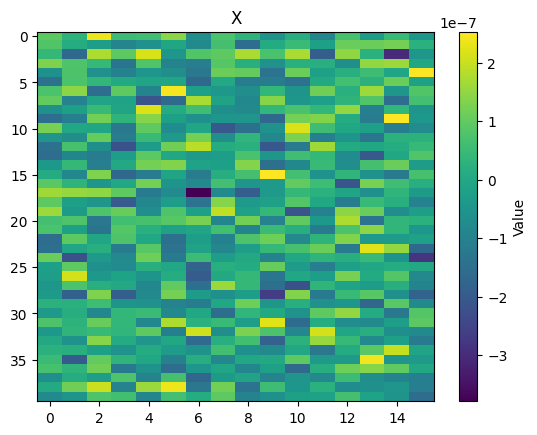

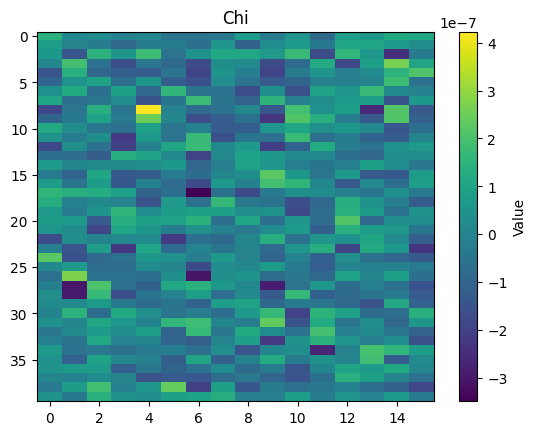

/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_50565/3006572819.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


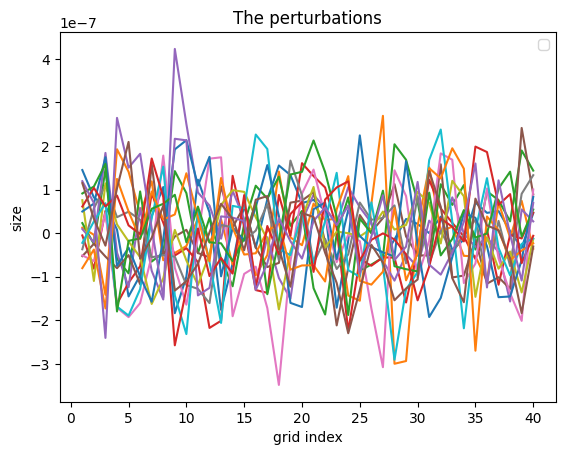

In [60]:
# We will now create the LETLM of the 21st row 
# The first step is to generate the ensembles of perturbations
ensemble_size = 16
X = torch.zeros(N, ensemble_size)
Chi = torch.zeros(N, ensemble_size)
x_out = x_g

for i in tqdm(range(ensemble_size)):
    x_pert = torch.randn(N,1)*sd
    # print(x_pert)
    x_in_pert = x_out + x_pert
    x_out_pert = model(x_in_pert,model_parameters)
    x_out_unpert = model(x_out, model_parameters)
    Chi_i = x_out_pert - x_out_unpert
    # print("x_out_pert shape:", x_out_pert.shape)
    # print("x_out_unpert shape:", x_out_unpert.shape)
    # print("Chi_i shape:", Chi_i.shape)
    X[:,i] = x_pert.squeeze()
    Chi[:,i] = Chi_i.squeeze()

    plt.plot(x_values, x_out_pert)
    plt.xlabel('perturbation size (10^(-x))')
    plt.ylabel('error')
    plt.title('The perturbed members')
    plt.legend()

plt.show()
plt.clf()


plt.imshow(X,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

plt.imshow(Chi,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Chi")
plt.show()

for i in range(ensemble_size):
    perts = Chi[:,i]
    plt.plot(x_values, perts)
    plt.xlabel('grid index')
    plt.ylabel('size')
    plt.title('The perturbations')
    plt.legend()



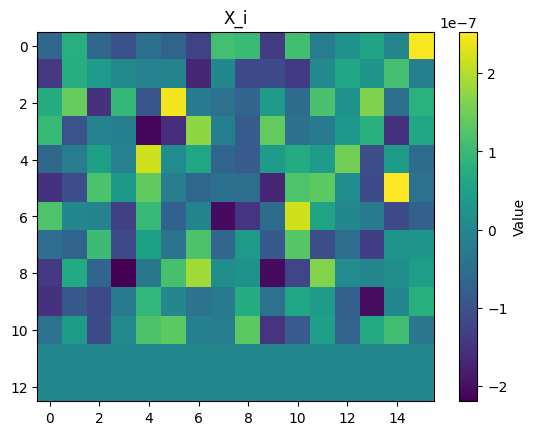

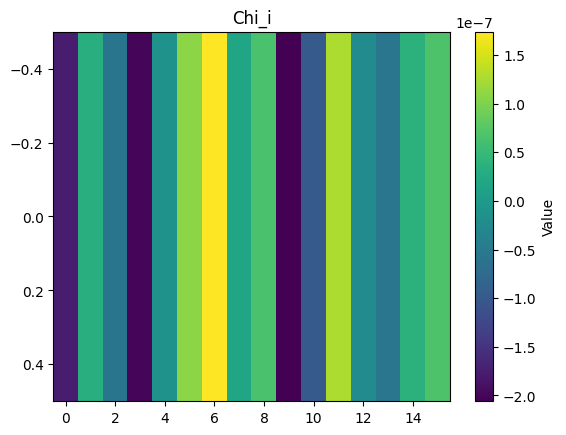

In [61]:
# Now that we have our ensembles we can select the required members to calculate the 21st row
# We set the grid index to 20

Chi_i = member_current_selector(grid_index,Chi,N,ensemble_size)
X_i = member_past_selector(grid_index,X,N,ensemble_size)

plt.imshow(X_i,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X_i")
plt.show()
plt.imshow(Chi_i,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Chi_i")
plt.show()


tensor([[ 7.8784e-05, -6.3292e-04,  3.9737e-03, -3.0520e-03, -3.5222e-02,
          2.0997e-02, -1.2109e-01,  1.9219e-01,  8.6913e-01,  1.7990e-01,
          3.1859e-02,  0.0000e+00,  0.0000e+00]])
tensor(0.8682)


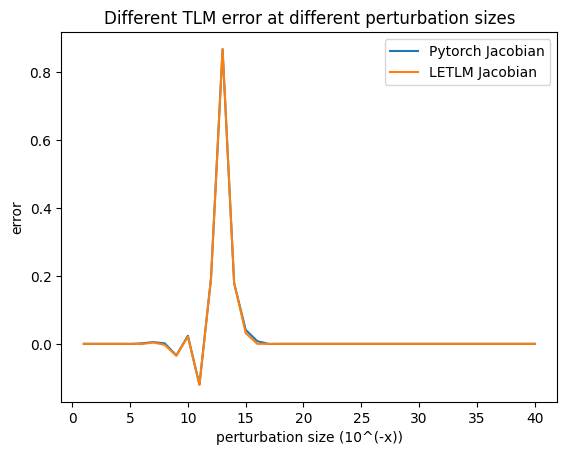

In [62]:
# We will now calculate M_i
M_i = little_LETLM(Chi_i, X_i)
print(M_i)
print(goal[grid_index])
M = torch.zeros(N,N)

M = put_in_place(M_i, N, M, grid_index)

LETLM_single = M[grid_index,:]


plt.plot(x_values, goal,label = 'Pytorch Jacobian' )
plt.plot(x_values, LETLM_single,label = 'LETLM Jacobian' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()
